# Task 2.2 — Reproduction of Sparse SVM Method

**Paper**:
 Efficient Variable Selection in Support Vector Machines via the Alternating Direction Method of Multipliers
(ICML 2011)

---

# Model Training: Sparse SVM

The main goal of the paper is to perform **feature selection while training a Support Vector Machine**. This is achieved by introducing an $L_1$ regularization term in the SVM optimization objective.

The optimization problem can be written as:

$$
\min_{w,b} \frac{1}{2}\|w\|_2^2
+ C \sum_{i=1}^{n} \max(0, 1 - y_i(w^T x_i + b))
+ \lambda \|w\|_1
$$

The $L_1$ regularization term encourages sparsity in the weight vector $w$. As a result, many weights become zero, effectively removing irrelevant features from the model.

In this reproduction experiment, we approximate this behaviour using a **linear SVM with L1 regularization**, which produces sparse model weights.

## Dataset Preparation

Since Jupyter notebooks execute independently, the dataset preparation steps are repeated here to ensure this notebook can run from start to finish without relying on variables from Task 2.1.


---

# Load Preprocessed Data from Task 2.1

This notebook continues from Task 2.1. We first load and preprocess the Breast Cancer Wisconsin dataset.

In [3]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (455, 30)
Test samples: (114, 30)


---

# Import Required Libraries

In [4]:
import numpy as np
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

---

# Train Sparse SVM Model

In [7]:
model = LinearSVC(
    penalty="l1",
    dual=False,
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l1'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rando

---

# Inspect Learned Weights

After training the model, we inspect the learned weight vector. Sparse models should have many weights equal to zero.

In [8]:
weights = model.coef_[0]

print("Number of features:", len(weights))
print("Number of non-zero weights:", np.sum(weights != 0))
print("Number of zero weights:", np.sum(weights == 0))

Number of features: 30
Number of non-zero weights: 22
Number of zero weights: 8


---

# Compute Sparsity Ratio

The sparsity ratio indicates how many features were effectively removed by the model.

In [9]:
sparsity_ratio = np.sum(weights == 0) / len(weights)

print("Sparsity ratio:", sparsity_ratio)

Sparsity ratio: 0.26666666666666666


A higher sparsity ratio indicates stronger feature selection.

---

# Identify Selected Features

Features with non-zero weights are considered selected by the model.

In [10]:
selected_features = feature_names[weights != 0]

print("Selected features:")
print(selected_features)

Selected features:
['mean texture' 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'area error' 'smoothness error'
 'compactness error' 'concavity error' 'concave points error'
 'symmetry error' 'fractal dimension error' 'worst texture' 'worst area'
 'worst smoothness' 'worst concavity' 'worst concave points'
 'worst symmetry']


These features contribute to the final classification decision.

---

# Feature Importance

The magnitude of the weight vector indicates how strongly each feature influences the classification boundary.

In [11]:
feature_importance = np.abs(weights)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
})

importance_df.sort_values(by="importance", ascending=False).head(10)

,feature,importance
23,worst area,2.024039
5,mean compactness,0.998114
26,worst concavity,0.900789
10,radius error,0.853704
7,mean concave points,0.766480
21,worst texture,0.690736
17,concave points error,0.527001
16,concavity error,0.488507
28,worst symmetry,0.364166
24,worst smoothness,0.321468


---

# Visualization of Feature Importance

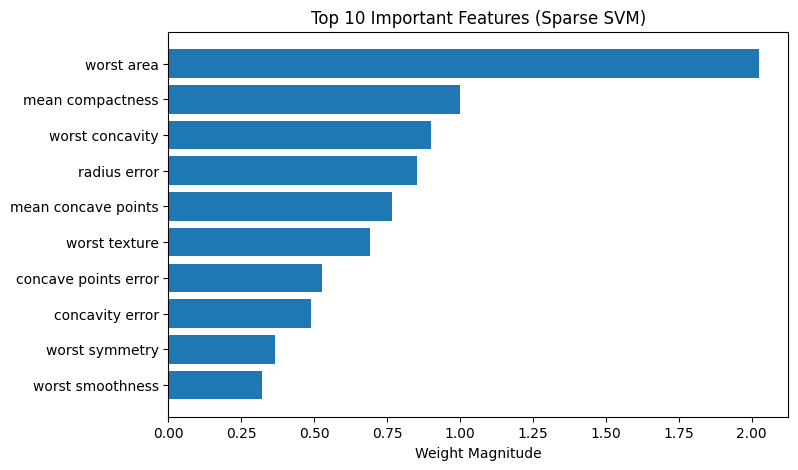

In [12]:
sorted_idx = np.argsort(feature_importance)[::-1]

top_features = feature_names[sorted_idx][:10]
top_values = feature_importance[sorted_idx][:10]

plt.figure(figsize=(8,5))

plt.barh(top_features, top_values)

plt.title("Top 10 Important Features (Sparse SVM)")
plt.xlabel("Weight Magnitude")

plt.gca().invert_yaxis()

plt.show()

---

# Preliminary Model Evaluation

Although full evaluation will be performed in Task 2.3, we compute a quick accuracy check.

In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", accuracy)

Test accuracy: 0.9736842105263158


---

# Discussion

The sparse SVM model successfully removes several features by assigning zero weights. This demonstrates the **feature selection property** described in the paper.

By enforcing sparsity in the model parameters, the classifier focuses only on the most informative features while ignoring redundant ones. This behaviour aligns with the goal of the ADMM-based optimization method proposed in the paper, which aims to efficiently perform variable selection during SVM training.